# Analyse Exploratoire des Données (EDA)
**Projet :** Prédiction de la mortalité infantile en Tunisie.
**Objectif de ce notebook :** Charger les données brutes de l'UNICEF, nettoyer les formats, et analyser visuellement les tendances et les distributions.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- CHARGEMENT DES DONNÉES ---")
DATA_PATH = '../data/UNICEF-CME_DF_2021_WQ-1.0-download (1).csv'
df_raw = pd.read_csv(DATA_PATH)
print(f"Lignes : {len(df_raw)} | Colonnes : {len(df_raw.columns)}")

--- CHARGEMENT DES DONNÉES ---
Lignes : 2400 | Colonnes : 44


In [ ]:
print("--- PRÉPARATION POUR L'ANALYSE ---")
df = df_raw.copy()

# Normaliser les noms
rename_map = {'Unit of measure': 'UNIT_MEASURE', 'Series Name': 'SERIES_NAME'}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
df = df.loc[:, ~df.columns.duplicated()]

# Conversions numériques
numeric_cols = ['REF_DATE', 'OBS_VALUE']
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# Suppression des doublons
df_clean = df.drop_duplicates().copy()
print(f"Données prêtes pour l'exploration : {len(df_clean)} lignes.")

--- PRÉPARATION POUR L'ANALYSE ---
Données prêtes pour l'exploration : 2400 lignes.


--- ANALYSE VISUELLE ---
Top 5 des valeurs manquantes (%) :
STATUS                    100.0
TIME_SINCE_FIRST_BIRTH    100.0
Age Group of Women        100.0
AGE_GROUP_OF_WOMEN        100.0
CATEGORY                  100.0
dtype: float64 



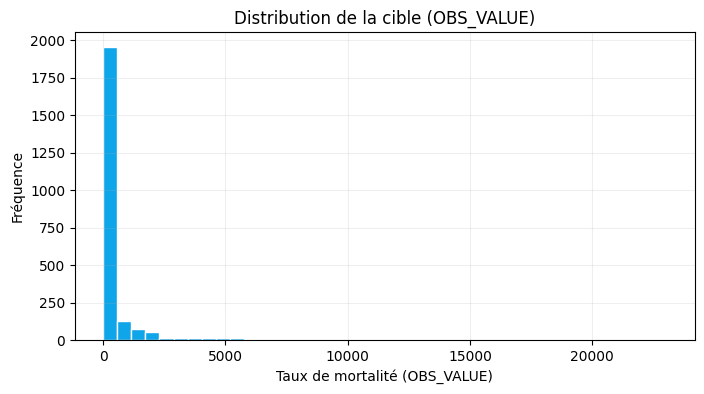

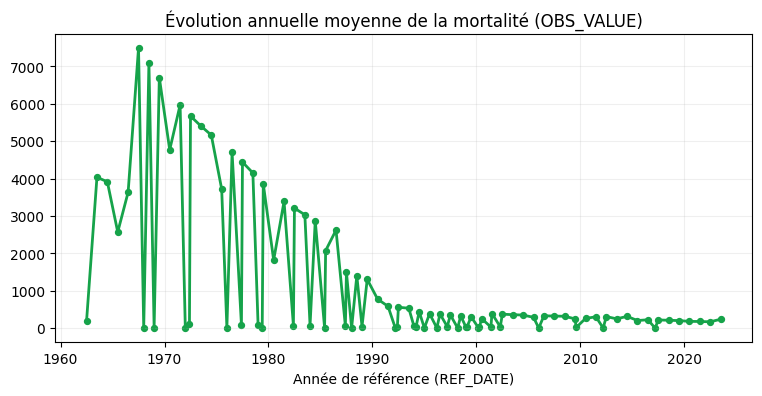

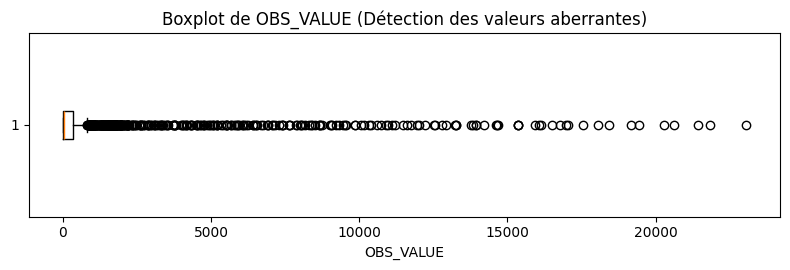

In [ ]:
print("--- ANALYSE VISUELLE ---")

# 1. Valeurs manquantes
print("Top 5 des valeurs manquantes (%) :")
print((df_clean.isna().mean() * 100).sort_values(ascending=False).head(5), "\n")

# 2. Distribution de la cible
plt.figure(figsize=(8, 4))
obs = df_clean['OBS_VALUE'].dropna()
plt.hist(obs, bins=40, color='#0ea5e9', edgecolor='white')
plt.title('Distribution de la cible (OBS_VALUE)')
plt.xlabel('Taux de mortalité (OBS_VALUE)')
plt.ylabel('Fréquence')
plt.grid(alpha=0.2)
plt.show()

# 3. Évolution annuelle moyenne
temp = df_clean[['REF_DATE', 'OBS_VALUE']].dropna()
yearly = temp.groupby('REF_DATE', as_index=False)['OBS_VALUE'].mean().sort_values('REF_DATE')
plt.figure(figsize=(9, 4))
plt.plot(yearly['REF_DATE'], yearly['OBS_VALUE'], color='#16a34a', linewidth=2)
plt.scatter(yearly['REF_DATE'], yearly['OBS_VALUE'], s=18, color='#16a34a')
plt.title('Évolution annuelle moyenne de la mortalité (OBS_VALUE)')
plt.xlabel('Année de référence (REF_DATE)')
plt.grid(alpha=0.2)
plt.show()

# 4. Boxplot (Outliers)
plt.figure(figsize=(8, 2.8))
plt.boxplot(obs, vert=False)
plt.title('Boxplot de OBS_VALUE (Détection des valeurs aberrantes)')
plt.xlabel('OBS_VALUE')
plt.tight_layout()
plt.show()